In [1]:
# Install necessary packages
!pip install tensorflow
!pip install scikit-learn
!pip install pandas
!pip install numpy
!pip install seaborn
!pip install matplotlib

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import random as python_random
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.models import load_model

In [3]:
# This code stop randomness for reproducibility
def reset_seeds():
   np.random.seed(42) 
   python_random.seed(42)
   tf.random.set_seed(42)

reset_seeds()

In [4]:
# load dataset
url = "https://raw.githubusercontent.com/TuhinPatra633/Career-Prediction-Using-Machine-Learning/main/Data/CareerMapping.csv"
df = pd.read_csv(url)
df.head()

,Database Fundamentals,Computer Architecture,Distributed Computing Systems,Cyber Security,Networking,Software Development,Programming Skills,Project Management,Computer Forensics Fundamentals,Technical Communication,...,Conscientousness,Extraversion,Agreeableness,Emotional_Range,Conversation,Openness to Change,Hedonism,Self-enhancement,Self-transcendence,Role
0,6,4,4,4,4,4,4,4,4,4,...,0.480564,0.470877,0.039611,0.742567,0.086927,0.339776,0.091158,0.230518,0.208746,Database Administrator
1,6,5,4,4,4,4,4,4,4,4,...,0.452903,0.377581,0.090148,0.672546,0.071425,0.353678,0.104495,0.247432,0.196424,Database Administrator
2,6,1,4,4,4,4,4,4,4,4,...,0.461668,0.347739,0.138575,0.630705,0.095261,0.375125,0.135462,0.287253,0.268024,Database Administrator
3,6,0,4,4,4,4,4,4,4,4,...,0.521783,0.403756,0.114925,0.695280,0.122656,0.338899,0.161705,0.306562,0.258119,Database Administrator
4,6,3,4,4,4,4,4,4,4,4,...,0.319539,0.240337,0.050988,0.619390,0.065564,0.311896,0.147700,0.302978,0.207287,Database Administrator


In [5]:
# here Data Preprocessing (Cleaning & Encoding)
# remove missing values
df = df.dropna()

# divide features (X) and target (y)
X = df.drop("Role", axis=1)
y = df['Role']

display(X.head(6))
display(X.shape)
display(y.head(6))
display(y.shape)


# One-hot encoding the target variable (y)
y_encoder = OneHotEncoder(sparse=False)
y_encodded = y_encoder.fit_transform(y.values.reshape(-1, 1))
display(y_encodded.shape)

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

,Database Fundamentals,Computer Architecture,Distributed Computing Systems,Cyber Security,Networking,Software Development,Programming Skills,Project Management,Computer Forensics Fundamentals,Technical Communication,...,Openness,Conscientousness,Extraversion,Agreeableness,Emotional_Range,Conversation,Openness to Change,Hedonism,Self-enhancement,Self-transcendence
0,6,4,4,4,4,4,4,4,4,4,...,0.714603,0.480564,0.470877,0.039611,0.742567,0.086927,0.339776,0.091158,0.230518,0.208746
1,6,5,4,4,4,4,4,4,4,4,...,0.617218,0.452903,0.377581,0.090148,0.672546,0.071425,0.353678,0.104495,0.247432,0.196424
2,6,1,4,4,4,4,4,4,4,4,...,0.814072,0.461668,0.347739,0.138575,0.630705,0.095261,0.375125,0.135462,0.287253,0.268024
3,6,0,4,4,4,4,4,4,4,4,...,0.607495,0.521783,0.403756,0.114925,0.695280,0.122656,0.338899,0.161705,0.306562,0.258119
4,6,3,4,4,4,4,4,4,4,4,...,0.781293,0.319539,0.240337,0.050988,0.619390,0.065564,0.311896,0.147700,0.302978,0.207287
5,6,2,4,4,4,4,4,4,4,4,...,0.700738,0.319925,0.246463,0.041292,0.624139,0.046333,0.336221,0.194156,0.312116,0.219690


(9179, 27)

0    Database Administrator
1    Database Administrator
2    Database Administrator
3    Database Administrator
4    Database Administrator
5    Database Administrator
Name: Role, dtype: object

(9179,)

(9179, 16)

In [6]:
# Split data for training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encodded, test_size=0.2, random_state=42)

print("Train data", X_train.shape)
print("Test data", X_test.shape)
print("Train target", y_train.shape)
print("Test target", y_test.shape)


Train data (7343, 27)
Test data (1836, 27)
Train target (7343, 16)
Test target (1836, 16)


In [7]:
# Building the model

# Create the model (empty model)
# Input layer + hidden layer and output layer
model = Sequential() 
model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))

model.add(Dense(32, activation='relu'))
model.add(Dropout(0.2)) # Dropout to prevent overfitting

model.add(Dense(y_encodded.shape[1], activation='softmax'))

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
summary = model.summary()

# Train the model
training_log = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test))

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                1792      
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dropout (Dropout)           (None, 32)                0         
                                                                 
 dense_2 (Dense)             (None, 16)                528       
                                                                 
Total params: 4,400
Trainable params: 4,400
Non-trainable params: 0
_________________________________________________________________
Epoch 1/50
230/230 [==============================] - 2s 5ms/step - loss: 2.2785 - accuracy: 0.3977 - val_loss: 1.5786 - val_accuracy: 0.7816
Epoch 2/50
230/230 [========================

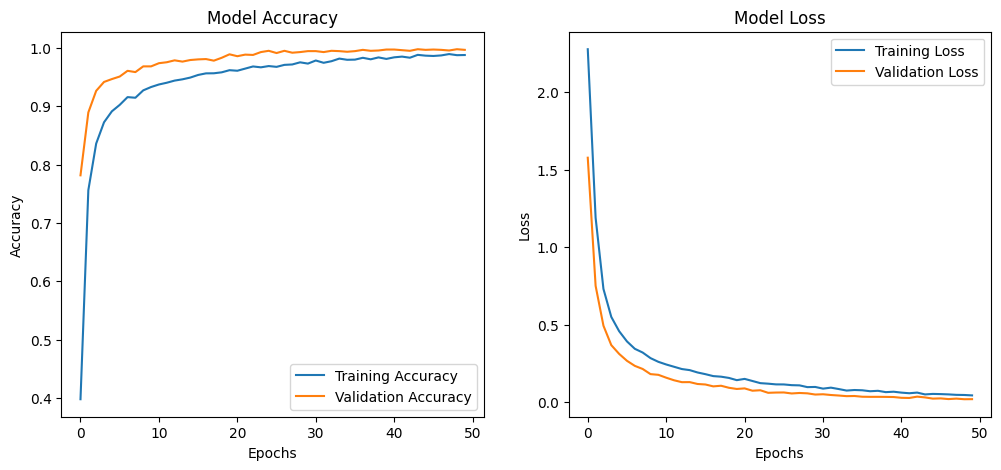

In [8]:
plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1,2,1)
plt.plot(training_log.history['accuracy'], label='Training Accuracy')
plt.plot(training_log.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(training_log.history['loss'], label='Training Loss')
plt.plot(training_log.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [9]:
# Classification report & confusion matrix

y_pred_prob = model.predict(X_test)
y_pred_classes = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

58/58 [==============================] - 0s 2ms/step


In [10]:
print(classification_report(y_true, y_pred_classes, target_names=y_encoder.categories_[0]))

                                 precision    recall  f1-score   support

               AI ML Specialist       1.00      0.99      0.99       230
                 API Specialist       1.00      1.00      1.00       103
   Application Support Engineer       1.00      1.00      1.00       115
               Business Analyst       1.00      0.99      1.00       108
     Customer Service Executive       1.00      1.00      1.00        99
      Cyber Security Specialist       1.00      1.00      1.00       104
         Database Administrator       1.00      1.00      1.00       120
              Graphics Designer       1.00      1.00      1.00        91
              Hardware Engineer       0.99      0.99      0.99       102
              Helpdesk Engineer       1.00      0.99      0.99       100
Information Security Specialist       1.00      1.00      1.00       105
            Networking Engineer       1.00      1.00      1.00       105
                Project Manager       0.99      1.

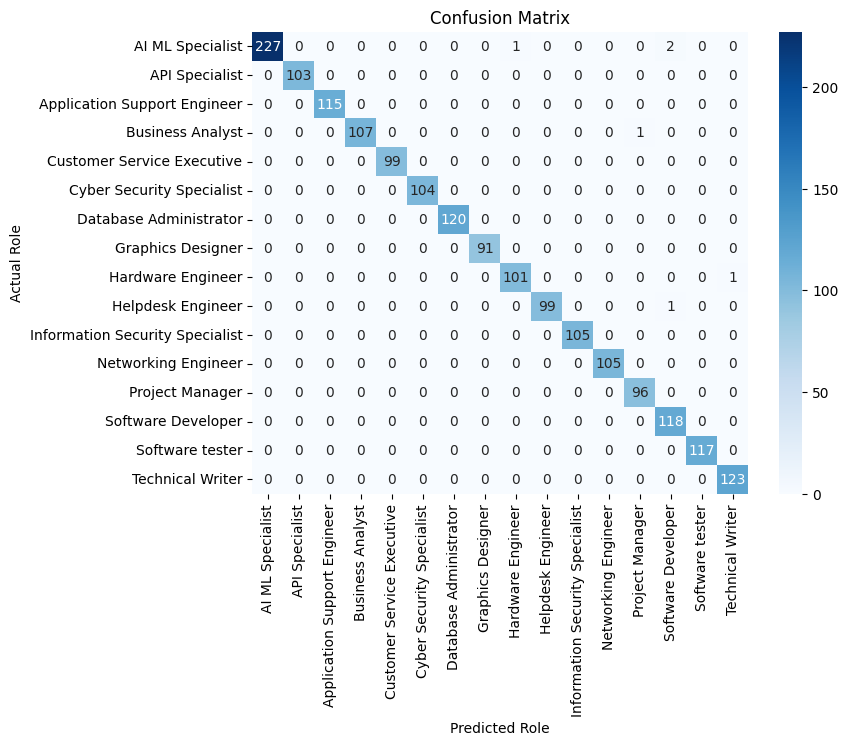

In [11]:
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=y_encoder.categories_[0],
            yticklabels=y_encoder.categories_[0])
plt.xlabel('Predicted Role')
plt.ylabel('Actual Role')
plt.title('Confusion Matrix')
plt.xticks(rotation=90)
plt.show()

In [12]:
# Final Accuracy
final_loss, final_acc = model.evaluate(X_test, y_test)
print(f"\nFinal Accuracy on Test Data: {final_acc * 100:.2f}%")

58/58 [==============================] - 0s 4ms/step - loss: 0.0208 - accuracy: 0.9967

Final Accuracy on Test Data: 99.67%


In [13]:
# Prediction new student

# sample new student data
new_student_data = {
    'Database Fundamentals': 2,
    'Computer Architecture': 2,
    'Distributed Computing Systems': 5,
    'Cyber Security': 3,
    'Networking': 2,
    'Software Development': 4,
    'Programming Skills': 4,
    'Project Management': 4,
    'Computer Forensics Fundamentals': 1,
    'Technical Communication': 6,
    'AI ML': 5,
    'Software Engineering': 4,
    'Business Analysis': 4,
    'Communication skills': 2,
    'Data Science': 2,
    'Troubleshooting skills': 6,
    'Graphics Designing': 5,
    'Openness': 0.38,
    'Conscientousness': 0.26,
    'Extraversion': 0.66,
    'Agreeableness': 0.72,
    'Emotional_Range': 0.68,
    'Conversation':0.36,
    'Openness to Change': 0.66,
    'Hedonism': 0.12,
    'Self-enhancement': 0.25,
    'Self-transcendence':0.69
}

# here  convert to dataFrame
input_df = pd.DataFrame([new_student_data])

# scale  data
input_scaled = scaler.transform(input_df)

# predict
prediction_prob = model.predict(input_scaled)
predicted_index = np.argmax(prediction_prob)
predicted_job = y_encoder.categories_[0][predicted_index]
confidence = prediction_prob[0][predicted_index] * 100

print(f"Suggested Job Role: {predicted_job}")
print(f"Confidence Score: {confidence:.2f}%")


1/1 [==============================] - 0s 51ms/step
Suggested Job Role: Software Developer
Confidence Score: 74.59%


In [14]:
import pickle

# Save model (creates a folder)
model.save("career_prediction_model")

# Save scaler
pickle.dump(scaler, open("scaler.pkl", "wb"))

# Save label encoder
pickle.dump(y_encoder, open("label_encoder.pkl", "wb"))

print("Saved successfully!")

INFO:tensorflow:Assets written to: career_prediction_model\assets
Saved successfully!


In [15]:
from tensorflow.keras.models import load_model

model = load_model("career_prediction_model")